## Problem statement

Can a neural network recognize which animal I drew?

We will build a **multiclass animal drawing classifier** using Google's [Quick, Draw! dataset](https://github.com/googlecreativelab/quickdraw-dataset).

Each drawing is a `28 × 28` grayscale image, and our model must decide which animal it represents:

- cat
- rabbit
- elephant
- fish
- butterfly

We load 5,000 drawings per animal: 25,000 images in total. These are hand-drawn sketches, not photographs.


In [1]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import helpers
from helpers.load_data import load_quickdraw
from helpers.activation_functions import relu, softmax

# Jupyter caches imports: reload edits to helpers.py before training again.
importlib.reload(helpers)

<module 'helpers' (namespace) from ['/Users/bentan/Codebase/ml/ml-series/notebooks/day-5/helpers']>

In [2]:
classes = ["cat", "rabbit", "elephant", "fish", "butterfly"]
X, y = load_quickdraw(classes, samples_per_class=5_000)

print("Images (X):", X.shape)
print("Labels (y):", y.shape)

Loading cat drawings...
Loading rabbit drawings...
Loading elephant drawings...
Loading fish drawings...
Loading butterfly drawings...
Images (X): (25000, 28, 28)
Labels (y): (25000,)


## Visualize the data

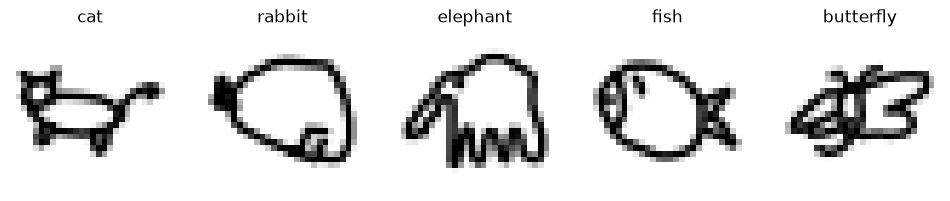

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for label, ax in enumerate(axes):
    ax.imshow(X[y == label][0], cmap="gray_r")
    ax.set_title(classes[label])
    ax.axis("off")

plt.show()

In [4]:
INPUT_NEURONS_COUNT = 28 * 28
HIDDEN_NEURONS_COUNT = 100
OUTPUT_NEURONS_COUNT = len(classes)

<img src="img/architecture.png" alt="Neural network architecture" width="500">

In [5]:
# Reproducible initialization; He scaling suits the hidden ReLU layer.
rng = np.random.default_rng(42)
HIDDEN_NEURON_WEIGHTS = rng.normal(
    0,
    np.sqrt(2 / INPUT_NEURONS_COUNT),
    size=(HIDDEN_NEURONS_COUNT, INPUT_NEURONS_COUNT),
)
HIDDEN_NEURON_BIAS = np.zeros(HIDDEN_NEURONS_COUNT)
OUTPUT_NEURON_WEIGHTS = rng.normal(
    0,
    np.sqrt(1 / HIDDEN_NEURONS_COUNT),
    size=(OUTPUT_NEURONS_COUNT, HIDDEN_NEURONS_COUNT),
)
OUTPUT_NEURON_BIAS = np.zeros(OUTPUT_NEURONS_COUNT)

print("Hidden neuron weights:", HIDDEN_NEURON_WEIGHTS.shape)
print("Hidden neuron bias:", HIDDEN_NEURON_BIAS.shape)
print("Output neuron weights:", OUTPUT_NEURON_WEIGHTS.shape)
print("Output neuron bias:", OUTPUT_NEURON_BIAS.shape)

Hidden neuron weights: (100, 784)
Hidden neuron bias: (100,)
Output neuron weights: (5, 100)
Output neuron bias: (5,)


## Prepare training and test data

<img src="img/data.png" alt="Training data" width="500">

In [6]:
# Flatten each 28 × 28 image into 784 pixels
X_flat = X.reshape(X.shape[0], 28 * 28)

# Split the images and integer labels
split_index = int(len(X_flat) * 0.8)

X_train = X_flat[:split_index]
y_train = y[:split_index]

X_test = X_flat[split_index:]
y_test = y[split_index:]

# Convert integer labels into one-hot vectors
Y_train = np.eye(len(classes))[y_train]
Y_test = np.eye(len(classes))[y_test]

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_train: (20000, 784)
Y_train: (20000, 5)
X_test: (5000, 784)
Y_test: (5000, 5)


<img src="img/forward-prop.png" alt="Forward propagation" width="500">

In [7]:
def forward_propogation(
    X: np.ndarray, W1: np.ndarray, b1: np.ndarray, W2: np.ndarray, b2: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    Z1 = X @ W1.T + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2.T + b2
    y_predicted = softmax(Z2)

    return A1, y_predicted

<img src="img/back_prop.png" alt="Backpropagation" width="500">

In [8]:
def back_propogation(
    X: np.ndarray,
    A1: np.ndarray,
    y_predicted: np.ndarray,
    Y: np.ndarray,
    W2: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    m = X.shape[0]

    # hidden layer -> output layergradient
    dz2 = (y_predicted - Y) / m  # Softmax + cross-entropy derivative
    dW2 = dz2.T @ A1
    db2 = np.sum(dz2, axis=0)

    # input layer -> hidden layer gradient
    dz1 = (dz2 @ W2) * (A1 > 0)  # ReLU derivative
    dW1 = dz1.T @ X
    db1 = np.sum(dz1, axis=0)

    return dW1, db1, dW2, db2

In [9]:
def update_parameters(
    W1: np.ndarray,
    b1: np.ndarray,
    W2: np.ndarray,
    b2: np.ndarray,
    dW1: np.ndarray,
    db1: np.ndarray,
    dW2: np.ndarray,
    db2: np.ndarray,
    learning_rate: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    return W1, b1, W2, b2

In [10]:
def calculate_loss(y_predicted: np.ndarray, Y: np.ndarray) -> float:
    """Mean categorical cross-entropy for one-hot labels."""
    probabilities = np.clip(y_predicted, 1e-15, 1.0)
    return float(-np.mean(np.sum(Y * np.log(probabilities), axis=1)))

In [11]:
def calculate_accuracy(y_predicted: np.ndarray, Y: np.ndarray) -> float:
    """Fraction of examples whose most likely class matches the label."""
    return float(np.mean(np.argmax(y_predicted, axis=1) == np.argmax(Y, axis=1)))

In [12]:
def train(
    X: np.ndarray,
    Y: np.ndarray,
    W1: np.ndarray,
    b1: np.ndarray,
    W2: np.ndarray,
    b2: np.ndarray,
    epochs: int = 100,
    learning_rate: float = 0.1,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, dict]:
    """Use the whole training set for one gradient descent step per epoch."""
    W1, b1, W2, b2 = (p.copy() for p in (W1, b1, W2, b2))
    history = {"loss": [], "accuracy": []}

    for epoch in range(epochs):
        A1, y_predicted = forward_propogation(X, W1, b1, W2, b2)
        loss = calculate_loss(y_predicted, Y)
        if not np.isfinite(loss):
            raise FloatingPointError("Loss is not finite. Check softmax and the learning rate.")
        accuracy = calculate_accuracy(y_predicted, Y)

        gradients = back_propogation(X, A1, y_predicted, Y, W2)
        W1, b1, W2, b2 = update_parameters(
            W1, b1, W2, b2, *gradients, learning_rate
        )

        # Record metrics from the forward pass before this epoch's update.
        history["loss"].append(loss)
        history["accuracy"].append(accuracy)
        if epoch % 100 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch + 1}/{epochs}: loss={loss:.4f}, accuracy={accuracy:.2%}")

    return W1, b1, W2, b2, history


In [13]:
W1, b1, W2, b2, history = train(
    X_train,
    Y_train,
    HIDDEN_NEURON_WEIGHTS,
    HIDDEN_NEURON_BIAS,
    OUTPUT_NEURON_WEIGHTS,
    OUTPUT_NEURON_BIAS,
    epochs=1000,
    learning_rate=0.25,
)

Epoch 1/1000: loss=1.7434, accuracy=17.47%
Epoch 101/1000: loss=0.7779, accuracy=71.68%
Epoch 201/1000: loss=0.6581, accuracy=77.02%
Epoch 301/1000: loss=0.5822, accuracy=80.24%
Epoch 401/1000: loss=0.5247, accuracy=82.12%
Epoch 501/1000: loss=0.4820, accuracy=83.86%
Epoch 601/1000: loss=0.4519, accuracy=84.81%
Epoch 701/1000: loss=0.4184, accuracy=86.06%
Epoch 801/1000: loss=0.3942, accuracy=86.86%
Epoch 901/1000: loss=0.3633, accuracy=88.12%
Epoch 1000/1000: loss=0.3441, accuracy=88.64%


In [14]:
_, test_probabilities = forward_propogation(X_test, W1, b1, W2, b2)
test_predictions = np.argmax(test_probabilities, axis=1)

print(f"Test loss: {calculate_loss(test_probabilities, Y_test):.4f}")
print(f"Test accuracy: {calculate_accuracy(test_probabilities, Y_test):.2%}")
print(f"Uniform random-guess baseline: {1 / len(classes):.2%}")

Test loss: 0.5324
Test accuracy: 81.14%
Uniform random-guess baseline: 20.00%


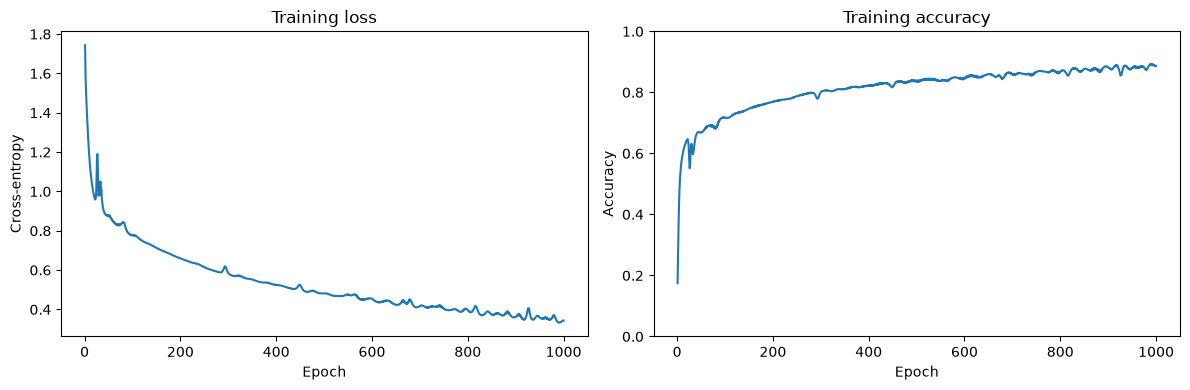

In [15]:
epoch_numbers = np.arange(1, len(history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epoch_numbers, history["loss"])
axes[0].set(title="Training loss", xlabel="Epoch", ylabel="Cross-entropy")
axes[1].plot(epoch_numbers, history["accuracy"])
axes[1].set(title="Training accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1))
plt.tight_layout()
plt.show()

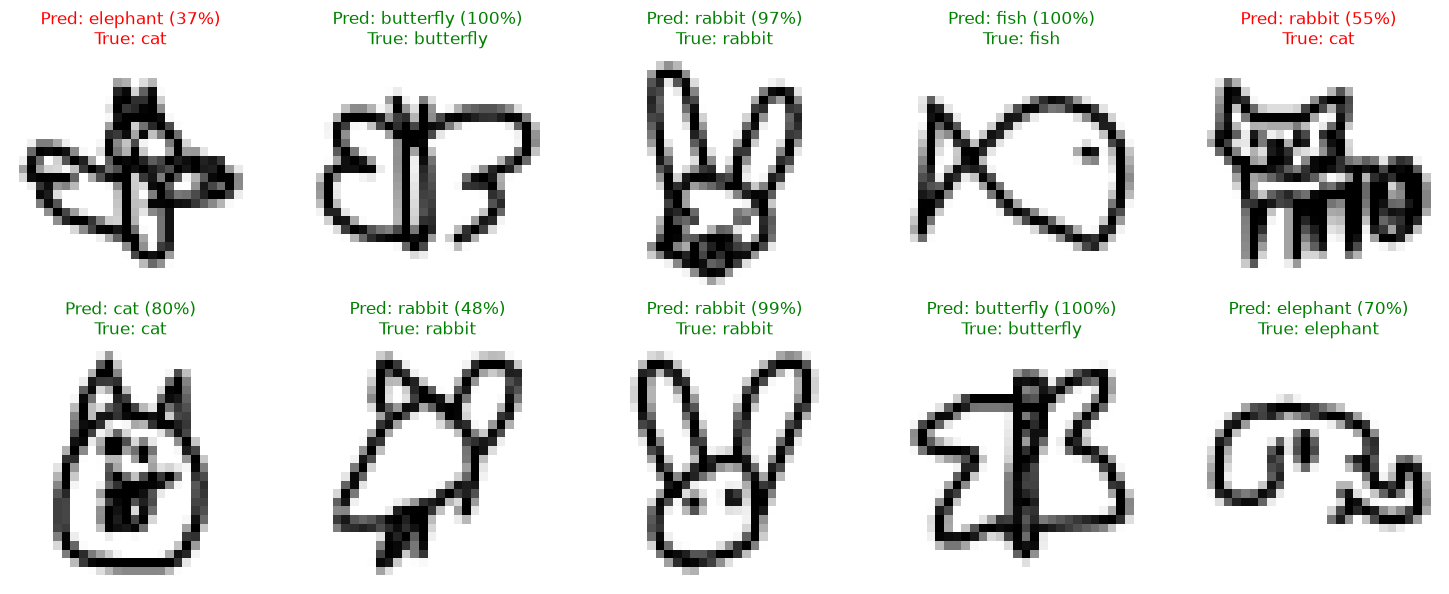

In [16]:
sample_indices = np.random.default_rng(7).choice(len(X_test), size=10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, index in zip(axes.flat, sample_indices):
    predicted = test_predictions[index]
    actual = y_test[index]
    confidence = test_probabilities[index, predicted]
    ax.imshow(X_test[index].reshape(28, 28), cmap="gray_r")
    ax.set_title(
        f"Pred: {classes[predicted]} ({confidence:.0%})\nTrue: {classes[actual]}",
        color="green" if predicted == actual else "red",
    )
    ax.axis("off")
plt.tight_layout()
plt.show()